In [2]:
import pandas as pd
import numpy as np
import gzip
import pysam
import linearmodels
from matplotlib import pyplot as plt
import seaborn as sns
import os

In [3]:
def get_cumulative(x, steps = 100):
    '''
    Function to get cumulative distribution.
    '''
    x = np.array(x)
    X = np.linspace(np.min(x), np.max(x), steps)
    y = [np.mean(x<=z) for z in X]
    return X, y

def prepare_qq(y_):

    min_non_zero = np.min([x for x in y_ if x > 0])

    y_ = np.maximum(np.array(y_), min_non_zero)
    y = sorted(-np.log10(np.array(y_)))
    x = sorted(-np.log10(np.linspace(1, len(y)+1, len(y))/len(y)))
    return x, y
    

In [11]:
tissues = sorted(os.listdir('/project/yangili1/cfbuenabadn/SpliFi/code/results/pheno/noisy/GTEx/'))

In [19]:
testis_pr = pd.read_csv('../code/results/mr_2sls/Cells-Culturedfibroblasts_PR.tab.gz', sep='\t')
testis_up = pd.read_csv('../code/results/mr_2sls/Cells-Culturedfibroblasts_UP.tab.gz', sep='\t')

mx_up, my_up = get_cumulative(testis_up.loc[(testis_up.F >= 10) & (testis_up.pval1 <= 1e-10)].groupby('gene').intron_gene_beta.median())
mx_pr, my_pr = get_cumulative(testis_pr.loc[(testis_pr.F >= 10) & (testis_pr.pval1 <= 1e-10)].groupby('gene').intron_gene_beta.median())

x_up, y_up = get_cumulative(testis_up.loc[testis_up.F >= 10].intron_gene_beta)
x_pr, y_pr = get_cumulative(testis_pr.loc[testis_pr.F >= 10].intron_gene_beta)




Text(0.5, 1.0, '2SLS (Muscle - Skeletal), eQTL pval <= 1e-10')

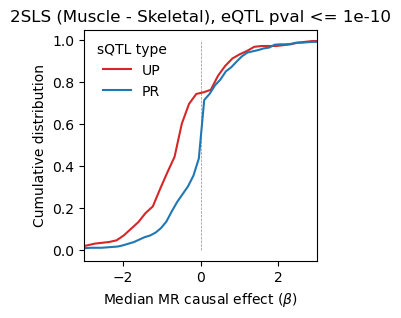

In [20]:
fig, ax = plt.subplots(figsize=(3,3))
ax.plot([0, 0], [0, 1], c='grey', linestyle='--', linewidth=0.5, alpha = 0.9)
# ax.plot(x_up, y_up, c='tab:red', label='UP', linestyle='--')
# ax.plot(x_pr, y_pr, c='tab:blue', label='PR', linestyle='--')

ax.plot(mx_up, my_up, c='tab:red', label='UP')
ax.plot(mx_pr, my_pr, c='tab:blue', label='PR')
# plt.plot(sx_up, sy_up, c='tab:red')
# plt.plot(sx_pr, sy_pr, c='tab:blue')
ax.set_xlim([-3, 3])
ax.legend(frameon=False, title='sQTL type')
ax.set_xlabel(r'Median MR causal effect $(\beta)$')
ax.set_ylabel('Cumulative distribution')
ax.set_title('2SLS (Muscle - Skeletal), eQTL pval <= 1e-10')

In [22]:
sqtl_stats = pd.read_csv('../code/analysis_files/sQTL_stats.tsv.gz', sep='\t')

In [30]:
# sqtl_stats.loc[sqtl_stats.sqtl_type == 'u_sqtl'].sort_values('spearman_pval').tissue

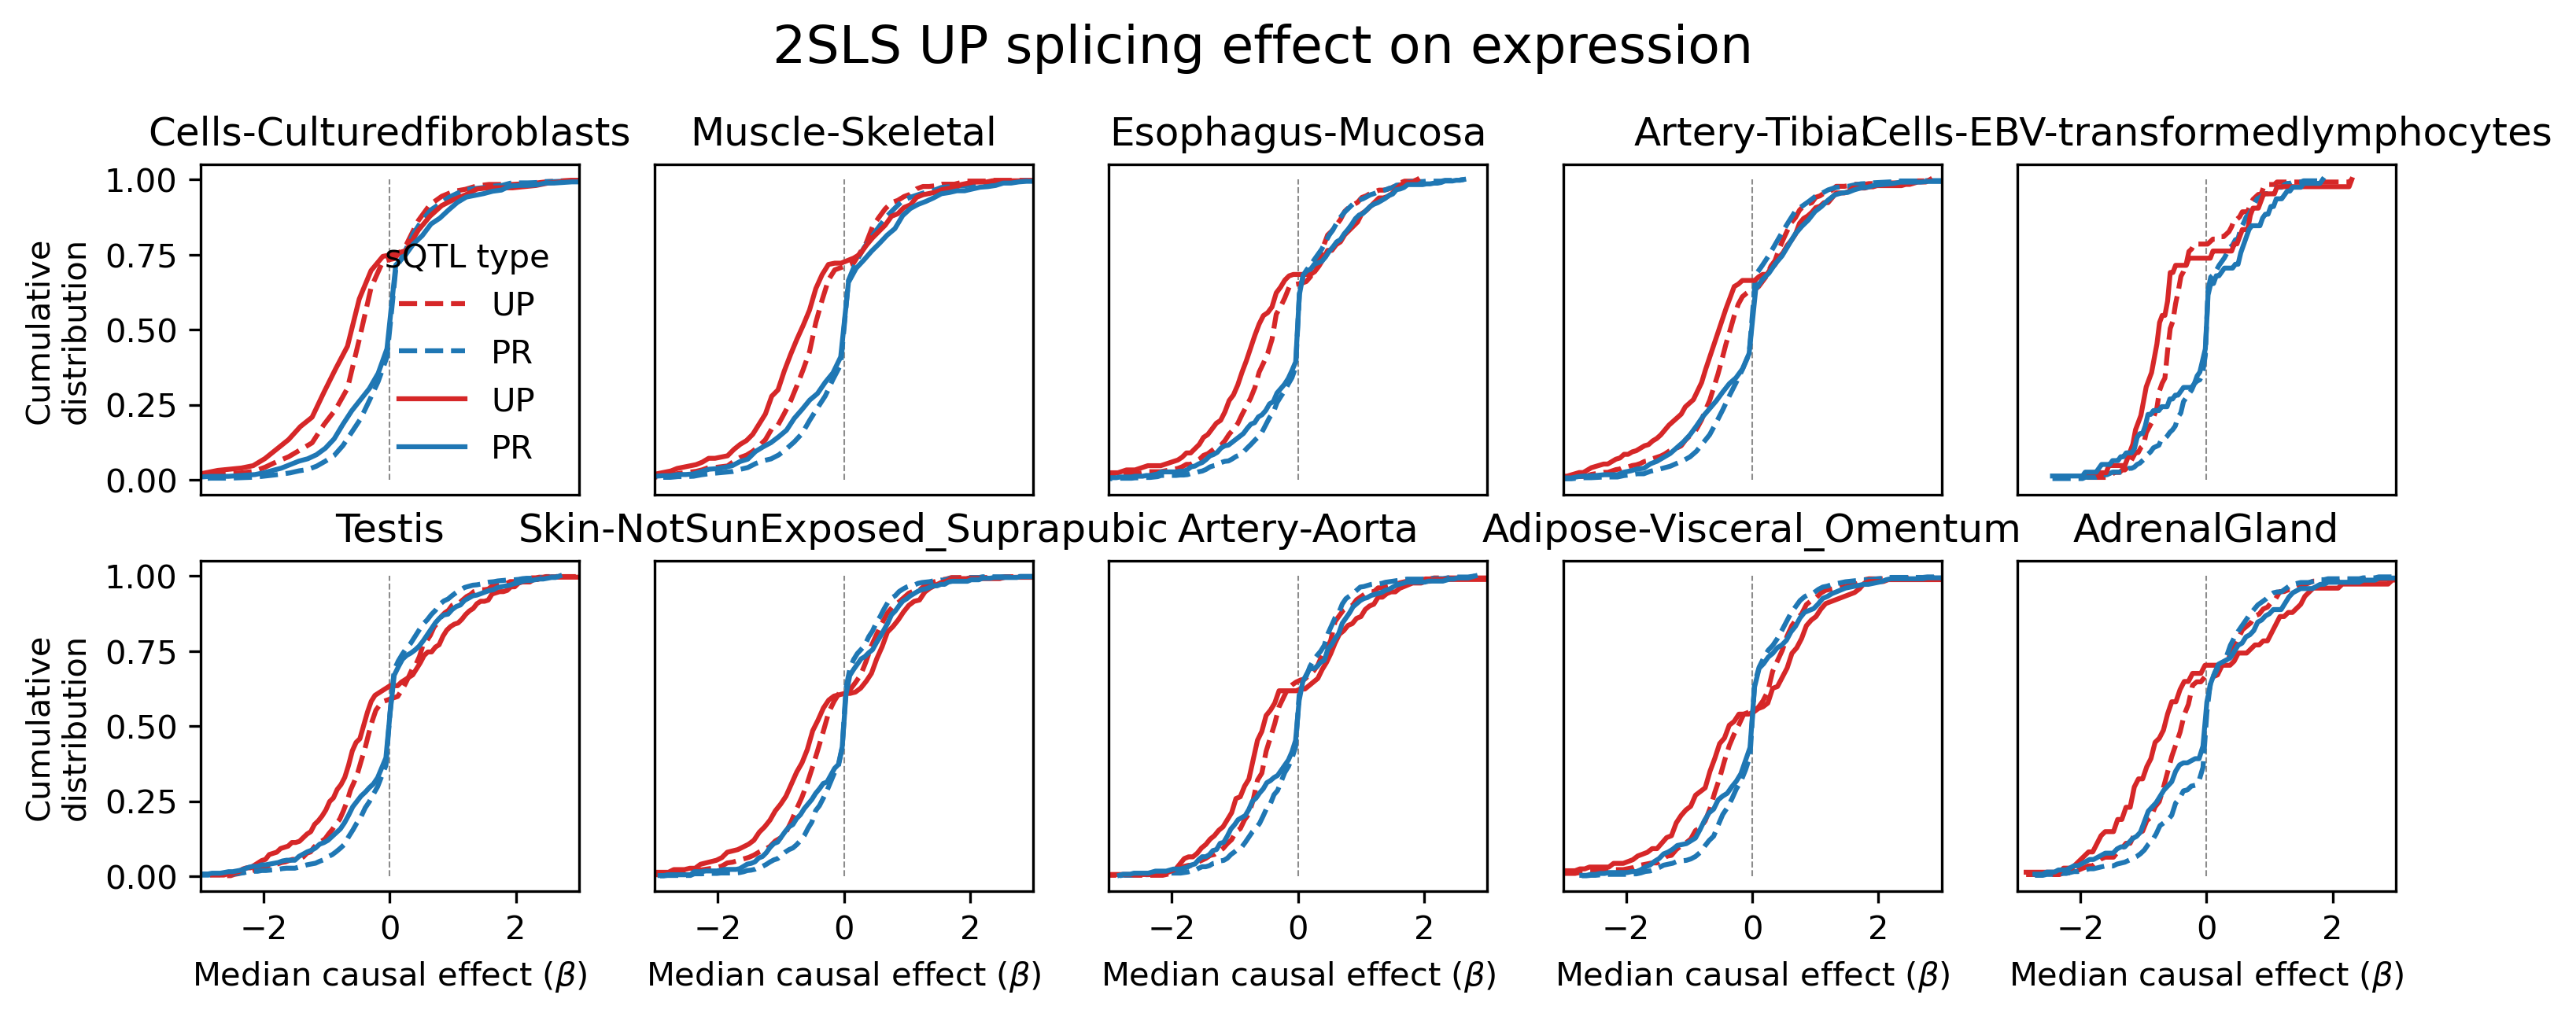

In [52]:
fig, ax = plt.subplots(2, 5, figsize=(12, 4), dpi=300)
i = 0
j = 0

sorted_tissues = list(sqtl_stats.loc[sqtl_stats.sqtl_type == 'u_sqtl'].sort_values('spearman_pval').tissue)

for tissue in sorted_tissues[:10]:


    tissue_pr = pd.read_csv(f'../code/results/mr_2sls/{tissue}_PR.tab.gz', sep='\t')
    tissue_up = pd.read_csv(f'../code/results/mr_2sls/{tissue}_UP.tab.gz', sep='\t')
    
    mx_up, my_up = get_cumulative(tissue_up.loc[(tissue_up.F >= 10) & (tissue_up.pval1 <= 1e-4)].groupby('gene').intron_gene_beta.median())
    mx_pr, my_pr = get_cumulative(tissue_pr.loc[(tissue_pr.F >= 10) & (tissue_pr.pval1 <= 1e-4)].groupby('gene').intron_gene_beta.median())

    
    # x_up, y_up = get_cumulative(tissue_up.loc[tissue_up.F >= 10].intron_gene_beta)
    # x_pr, y_pr = get_cumulative(tissue_pr.loc[tissue_pr.F >= 10].intron_gene_beta)


    

    ax[i,j].plot([0, 0], [0, 1], c='grey', linestyle='--', linewidth=0.5, alpha = 0.9)
    
    ax[i,j].plot(mx_up, my_up, c='tab:red', label='UP', linestyle='--')
    ax[i,j].plot(mx_pr, my_pr, c='tab:blue', label='PR', linestyle='--')


    mx_up, my_up = get_cumulative(tissue_up.loc[(tissue_up.F >= 10) & (tissue_up.pval1 <= 1e-10)].groupby('gene').intron_gene_beta.median())
    mx_pr, my_pr = get_cumulative(tissue_pr.loc[(tissue_pr.F >= 10) & (tissue_pr.pval1 <= 1e-10)].groupby('gene').intron_gene_beta.median())

    ax[i,j].plot(mx_up, my_up, c='tab:red', label='UP')
    ax[i,j].plot(mx_pr, my_pr, c='tab:blue', label='PR')
    
    ax[i,j].set_xlim([-3, 3])

    if (i == 0) and (j == 0):
        ax[i,j].legend(frameon=False, title='sQTL type')

    
    if j == 0:
        ax[i,j].set_ylabel('Cumulative\ndistribution', size=10)
    else:
        ax[i,j].set_yticks([])
    
    
        
    if (i == 1):
        ax[i,j].set_xlabel('Median causal effect $(\\beta)$', size=10)
        # ax[i,j].set_xticks([-1, 0, 1, 2], ['0.1%', '1%', '10%', '100%'])
    else:
        ax[i,j].set_xticks([])  

    ax[i,j].set_title(tissue, size=12)

    j += 1
    if j >= 5:
        j = 0
        i += 1

fig.suptitle(r"2SLS UP splicing effect on expression", fontsize=16, y = 1.03)


plt.savefig('../code/revision_plots/MR_2SLS.slopes.png', dpi=300, bbox_inches='tight')
plt.savefig('../code/revision_plots/MR_2SLS.slopes.pdf', dpi=300, bbox_inches='tight')
plt.savefig('../code/revision_plots/MR_2SLS.slopes.svg', dpi=300, bbox_inches='tight')    

Text(0.5, 1.03, '2SLS UP splicing effect on expression, eQTL pval $\\leq 1e^{-10}$')

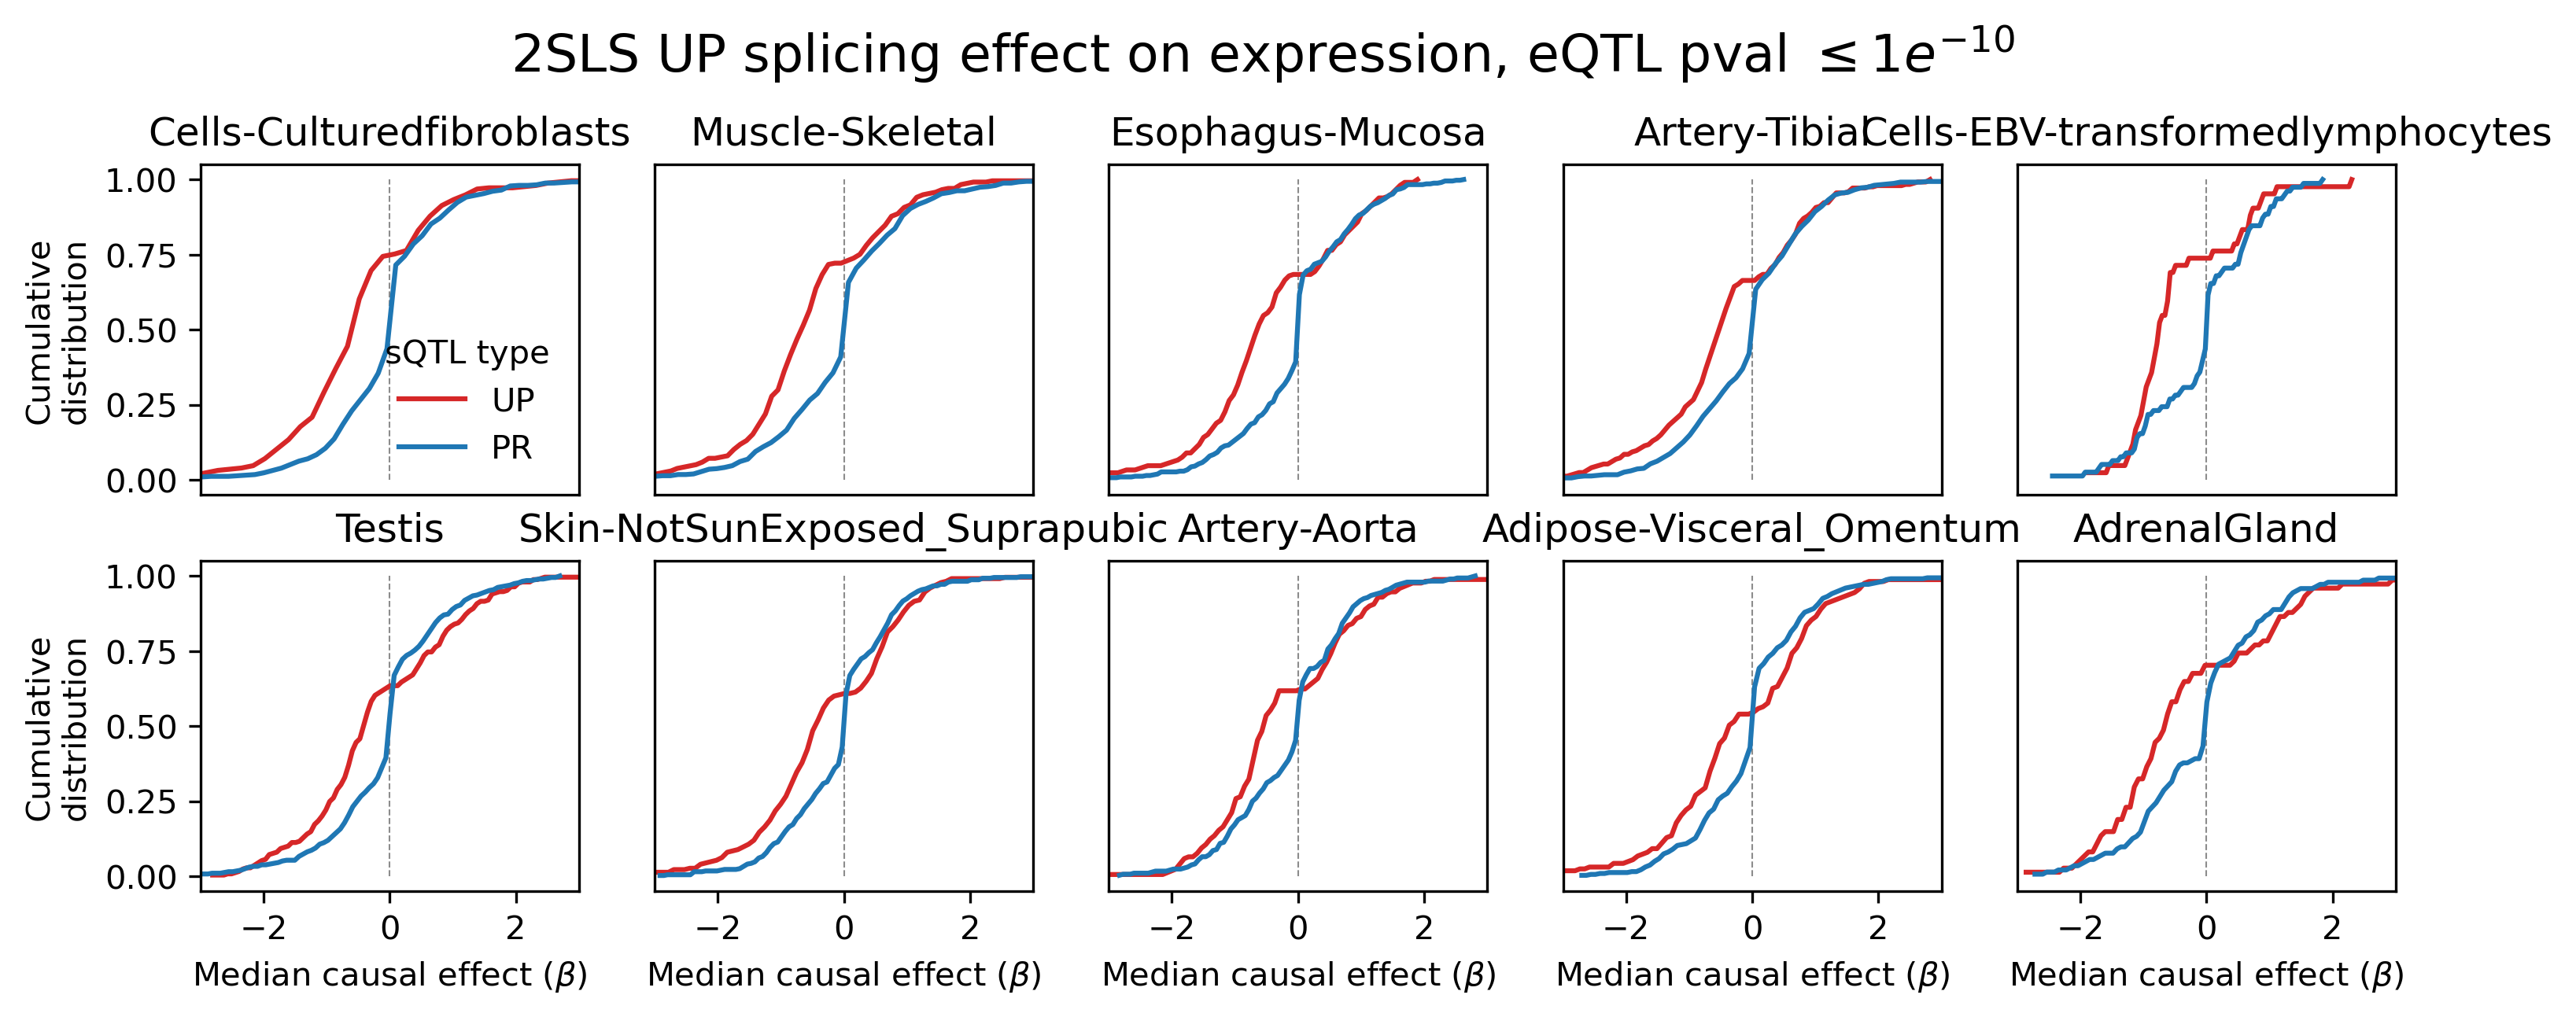

In [48]:
fig, ax = plt.subplots(2, 5, figsize=(12, 4), dpi=300)
i = 0
j = 0

sorted_tissues = list(sqtl_stats.loc[sqtl_stats.sqtl_type == 'u_sqtl'].sort_values('spearman_pval').tissue)

for tissue in sorted_tissues[:10]:


    tissue_pr = pd.read_csv(f'../code/results/mr_2sls/{tissue}_PR.tab.gz', sep='\t')
    tissue_up = pd.read_csv(f'../code/results/mr_2sls/{tissue}_UP.tab.gz', sep='\t')
    
    mx_up, my_up = get_cumulative(tissue_up.loc[(tissue_up.F >= 10) & (tissue_up.pval1 <= 1e-10)].groupby('gene').intron_gene_beta.median())
    mx_pr, my_pr = get_cumulative(tissue_pr.loc[(tissue_pr.F >= 10) & (tissue_pr.pval1 <= 1e-10)].groupby('gene').intron_gene_beta.median())
    
    # x_up, y_up = get_cumulative(tissue_up.loc[tissue_up.F >= 10].intron_gene_beta)
    # x_pr, y_pr = get_cumulative(tissue_pr.loc[tissue_pr.F >= 10].intron_gene_beta)


    

    ax[i,j].plot([0, 0], [0, 1], c='grey', linestyle='--', linewidth=0.5, alpha = 0.9)
    
    ax[i,j].plot(mx_up, my_up, c='tab:red', label='UP')
    ax[i,j].plot(mx_pr, my_pr, c='tab:blue', label='PR')

    ax[i,j].set_xlim([-3, 3])

    if (i == 0) and (j == 0):
        ax[i,j].legend(frameon=False, title='sQTL type')

    
    if j == 0:
        ax[i,j].set_ylabel('Cumulative\ndistribution', size=10)
    else:
        ax[i,j].set_yticks([])
    
    
        
    if (i == 1):
        ax[i,j].set_xlabel('Median causal effect $(\\beta)$', size=10)
        # ax[i,j].set_xticks([-1, 0, 1, 2], ['0.1%', '1%', '10%', '100%'])
    else:
        ax[i,j].set_xticks([])  

    ax[i,j].set_title(tissue, size=12)

    j += 1
    if j >= 5:
        j = 0
        i += 1

fig.suptitle(r"2SLS UP splicing effect on expression, eQTL pval $\leq 1e^{-10}$", fontsize=16, y = 1.03)


In [2]:
import pysam

vcf_in = pysam.VariantFile('/project2/yangili1/cfbuenabadn/torino_paper/code/resources/GTEx/genotype/GTEx_Analysis_2017-06-05_v8_WGS_VCF_files_GTEx_Analysis_2017-06-05_v8_WholeGenomeSeq_838Indiv_Analysis_Freeze.SHAPEIT2_phased.vcf.gz')  # automatically detects format
for record in vcf_in:
    print(record.chrom, record.pos, record.ref, record.alts)
    break


chr1 13526 C ('T',)


In [3]:
tissues = sorted(os.listdir('/project/yangili1/cfbuenabadn/SpliFi/code/results/pheno/noisy/GTEx/'))

In [ ]:
# var_id = "chr5_52897294_A_G_b38"

# gtex_vcf  = vcf.Reader(open('../code/resources/GTEx/genotype/GTEx_Analysis_2017-06-05_v8_WGS_VCF_files_GTEx_Analysis_2017-06-05_v8_WholeGenomeSeq_838Indiv_Analysis_Freeze.SHAPEIT2_phased.vcf.gz', 'br'))

# def get_snp_record(vcf, var_id):
#     chrom, position, ref, alt, _ = var_id.split('_')
#     position = int(position)
#     record_out = None
#     for record in vcf.fetch(chrom, position-1, position+1):  
#         if (record.POS == position) and (record.REF == ref) and (alt in record.ALT):
#             record_out = record
#     return record_out


# rec_ = get_snp_record(gtex_vcf, var_id)
# ref = rec_.REF
# alt = str(rec_.ALT[0])
# hom_refs = pd.Index([x.sample for x in rec_.get_hom_refs()])
# hets = pd.Index([x.sample for x in rec_.get_hets()])
# hom_alts = pd.Index([x.sample for x in rec_.get_hom_alts()])

In [4]:
# ms_perm = pd.read_csv('../code/results/sqtl/GTEx/Muscle-Skeletal/cis_100000/perm/PermutationPass.Qval.txt.gz', sep='\t')

In [5]:
# ms_perm.loc[ms_perm.ctype == 'PR,UP']

In [4]:
def get_intron_list(tissue):
    intron_list = []
    cluster_list = []
    median_count_list = []
    with gzip.open(
        f'/project/yangili1/cfbuenabadn/SpliFi/code/results/pheno/noisy/GTEx/{tissue}/leafcutter_perind_numers.counts.noise_by_intron.gz'
    ) as fh:
        fh.readline()
        for line in fh:
            line = line.decode().rstrip().split(' ')
            intron_list.append(line[0])
            cluster_list.append(line[0].split(':')[0] + ':' + line[0].split(':')[-2])
            median_counts = int(np.median([int(y) for y in line[1:]]))
            median_count_list.append(median_counts)

    intron_median_counts = pd.DataFrame()
    intron_median_counts['phenotype_id'] = intron_list
    intron_median_counts['cluster'] = cluster_list
    intron_median_counts['median_counts'] = median_count_list
    intron_median_counts['intron'] = intron_median_counts.phenotype_id.apply(lambda x: ':'.join(x.split(':')[:-1]))
    
    return intron_median_counts
    
def get_perm_counts(tissue):
#     results/sqtl/GTEx/Ovary/cis_100000/perm/PermutationPass.Qval.txt.gz
    perm = pd.read_csv(f'../code/results/sqtl/GTEx/{tissue}/cis_100000/perm/PermutationPass.Qval.txt.gz', sep='\t')
    intron_median_counts = get_intron_list(tissue)
    perm_counts = pd.merge(perm, intron_median_counts, right_on=['phenotype_id', 'intron', 'cluster'], 
         left_on=['phe_id', 'intron', 'cluster'])
    counts_per_cluster = perm_counts.groupby('cluster').median_counts.sum().reset_index()
    counts_per_cluster.columns = ['cluster', 'cluster_counts']

    counts_per_gene = perm_counts.groupby('gene_id').median_counts.sum().reset_index()
    counts_per_gene.columns = ['gene_id', 'gene_counts']
    
    perm_counts = pd.merge(perm_counts, counts_per_cluster, left_on='cluster', right_on='cluster')
    perm_counts = pd.merge(perm_counts, counts_per_gene, left_on='gene_id', right_on='gene_id')
    perm_counts['intron_psi'] = perm_counts.median_counts/(perm_counts.cluster_counts+1e-10)
    perm_counts['cluster_psi'] = perm_counts.cluster_counts/(perm_counts.gene_counts+1e-10)
    UP_per_cluster = perm_counts.groupby('cluster').itype.apply(lambda x: (x == 'UP').sum()).reset_index()
    UP_per_cluster.columns = ['cluster', 'UP_juncs']
    perm_counts = pd.merge(perm_counts, UP_per_cluster, left_on='cluster', right_on='cluster')
    
    return perm_counts


def get_expression_effect(tissue, perm_qtl):
    var_id = perm_qtl.var_id
    chrom = perm_qtl.var_chr
    start = str(int(perm_qtl.var_from) - 1)
    
    end = str(int(perm_qtl.var_to) + 1)
    
    coords = f'{chrom}:{start}:{end}'
    
    gene = perm_qtl.gene_id.split('.')[0]
            
    nom_file = f'/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/eqtl/GTEx/{tissue}/cis_100000/nom/{chrom}.txt.gz'
    nom_df = run_tabix_on_nom(nom_file, coords, gene=gene)

    # nom_df.set_index('#phe_id').T
    # return nom_df
    nom_df = nom_df.loc[nom_df['var_id'] == var_id]

    return nom_df



def run_tabix_on_nom(nom_file, coords, gene):
    chrom, start, end = coords.split(':')
    start = int(start)
    end = int(end)

    tb = pysam.TabixFile(nom_file)
    
    columns = tb.header[0].rstrip().split('\t')

    fields_dict = {'#phe_id':columns[1:]}
    for line in tb.fetch(chrom, start, end):
        fields = line.strip().split('\t')
        gene_name = fields[0].split('.')[0]
        # print(fields)
        if gene_name == gene:
            fields_dict.update({gene_name:fields[1:]})

    fields_df = pd.DataFrame(fields_dict).set_index('#phe_id').T
    return fields_df
    
    
#     if transform_to_df:
#         columns = ['#phe_id', 'phe_chr', 'phe_from', 'phe_to', 'phe_strd', 'n_var_in_cis', 'dist_phe_var', 'var_id', 
#                    'var_chr', 'var_from', 'var_to', 'nom_pval', 'r_squared', 'slope', 'slope_se', 'best_hit']
        
# #         columns = ['#phe_id', 'phe_chr', 'phe_from', 'phe_to', 'phe_strd', 'n_var_in_cis', 'dist_phe_var', 'var_id', 
# #                    'var_chr', 'var_from', 'var_to', 'nom_pval', 'r_squared', 'slope', 'slope_se', 'best_hit']

#         nom_bed = []#pd.DataFrame()
#         nom_bed_cols = []
        
#         # Iterate over queried junctions and store them in the DataFrame
#         for idx, record in enumerate(nom):
#             nom_bed.append(pd.Series(record))
#             nom_bed_cols.append(f'record{str(idx)}')
#             # junctions_bed[f'record{str(idx)}'] = record
#         # print(record)
#         # print(junctions_bed)
#         nom_bed = pd.concat(nom_bed, axis=1)
#         nom_bed.columns = nom_bed_cols
#         nom_bed = nom_bed.T
#         nom_bed.columns = columns
#         nom_bed['#phe_id'] = nom_bed['#phe_id'].apply(lambda x: x.split('.')[0])
#         return nom_bed
    
#     return nom

In [136]:
get_expression_effect('Muscle-Skeletal', perm_select.iloc[0])

#phe_id,phe_chr,phe_from,phe_to,phe_strd,n_var_in_cis,dist_phe_var,var_id,var_chr,var_from,var_to,nom_pval,r_squared,slope,slope_se,best_hit
ENSG00000188976,chr1,944203,959309,-,592,0,chr1_954333_C_A_b38,chr1,954333,954333,0.0027626,0.0126527,-0.100381,0.03342,0


In [7]:
perm_counts = get_perm_counts('Muscle-Skeletal')
ctype='PR,UP'
itype='UP'
qmax = 1e-1
clu_psi_min=0.1
perm_select = perm_counts.loc[(perm_counts.ctype == ctype) & (perm_counts.itype == itype) & (perm_counts.q <= qmax) & (perm_counts.cluster_psi >= clu_psi_min)]

#  ctype='PR,UP', itype='UP', qmax = 1e-1, clu_psi_min=0.1

In [8]:
perm_select.intron.iloc[0]

'chr1:954523:955922:clu_1985_-'

In [9]:
res_dir = '/project/yangili1/cfbuenabadn/SpliFi/code/results'
tissue = 'Muscle-Skeletal'
chrom = 'chr1'
sPheno = f'{res_dir}/pheno/noisy/GTEx/{tissue}/separateNoise/leafcutter.qqnorm_{chrom}.gz'
ePheno = f'{res_dir}/eqtl/GTEx/{tissue}/qqnorm.sorted.{chrom}.bed.gz'

In [13]:
perm_select.var_id

9            chr1_954333_C_A_b38
119         chr1_1374505_A_G_b38
188         chr1_1627156_G_A_b38
200         chr1_1696758_A_G_b38
247         chr1_1926870_T_C_b38
                  ...           
74911     chr22_46738358_A_G_b38
74937    chr22_49921859_C_CT_b38
74949     chr22_50208507_G_C_b38
74984     chr22_50260902_C_G_b38
75057     chr22_50624290_C_T_b38
Name: var_id, Length: 1355, dtype: object

In [10]:
res_dir = '/project/yangili1/cfbuenabadn/SpliFi/code/results'
tissue = 'Muscle-Skeletal'
chrom = 'chr1'
sPheno = f'{res_dir}/pheno/noisy/GTEx/{tissue}/separateNoise/leafcutter.qqnorm_{chrom}.gz'
ePheno = f'{res_dir}/eqtl/GTEx/{tissue}/qqnorm.sorted.{chrom}.bed.gz'
etbx = pysam.TabixFile(ePheno)
stbx = pysam.TabixFile(sPheno)

# Fetch by region
chrom = "chr1"
start = 954523
end = 955922

for line in etbx.fetch(chrom, start, end):
    fields = line.strip().split('\t')
    chrom, chrom_start, chrom_end = fields[:3]
    print(chrom, chrom_start, chrom_end)

chr1 944202 959309


In [50]:
perm_select

,intron,cluster,itype,ctype,gene_name,gene_id,phe_id,phe_chr,phe_from,phe_to,...,adj_emp_pval,adj_beta_pval,q,phenotype_id,median_counts,cluster_counts,gene_counts,intron_psi,cluster_psi,UP_juncs
9,chr1:954523:955922:clu_1985_-,chr1:clu_1985_-,UP,"PR,UP",NOC2L,ENSG00000188976.10,chr1:954523:955922:clu_1985_-:UP,chr1,954524,955922,...,0.000999,1.267740e-08,1.971100e-07,chr1:954523:955922:clu_1985_-:UP,4,127,535,0.031496,0.237383,1
119,chr1:1374590:1374704:clu_2012_-,chr1:clu_2012_-,UP,"PR,UP",AURKAIP1,ENSG00000175756.13,chr1:1374590:1374704:clu_2012_-:UP,chr1,1374591,1374704,...,0.000999,2.279890e-09,3.834200e-08,chr1:1374590:1374704:clu_2012_-:UP,6,506,907,0.011858,0.557883,1
188,chr1:1642508:1649498:clu_2023_-,chr1:clu_2023_-,UP,"PR,UP",CDK11B,ENSG00000248333.8,chr1:1642508:1649498:clu_2023_-:UP,chr1,1642509,1649498,...,0.000999,2.962930e-04,2.607200e-03,chr1:1642508:1649498:clu_2023_-:UP,11,199,246,0.055276,0.808943,1
200,chr1:1703995:1704222:clu_2028_-,chr1:clu_2028_-,UP,"PR,UP",CDK11A,ENSG00000008128.22,chr1:1703995:1704222:clu_2028_-:UP,chr1,1703996,1704222,...,0.000999,3.053460e-07,4.125700e-06,chr1:1703995:1704222:clu_2028_-:UP,56,90,398,0.622222,0.226131,1
247,chr1:1915735:1916751:clu_46_+,chr1:clu_46_+,UP,"PR,UP",CALML6,ENSG00000169885.9,chr1:1915735:1916751:clu_46_+:UP,chr1,1915736,1916751,...,0.000999,2.553270e-28,1.227800e-26,chr1:1915735:1916751:clu_46_+:UP,0,79,79,0.000000,1.000000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74911,chr22:46735508:46738006:clu_38294_-,chr22:clu_38294_-,UP,"PR,UP",CERK,ENSG00000100422.13,chr22:46735508:46738006:clu_38294_-:UP,chr22,46735509,46738006,...,0.002997,7.688870e-03,4.751000e-02,chr22:46735508:46738006:clu_38294_-:UP,2,14,14,0.142857,1.000000,1
74937,chr22:49921761:49921870:clu_37868_+,chr22:clu_37868_+,UP,"PR,UP",CRELD2,ENSG00000184164.14,chr22:49921761:49921870:clu_37868_+:UP,chr22,49921762,49921870,...,0.000999,1.096730e-06,1.389200e-05,chr22:49921761:49921870:clu_37868_+:UP,0,46,205,0.000000,0.224390,1
74949,chr22:50206520:50208487:clu_37875_+,chr22:clu_37875_+,UP,"PR,UP",SELENOO,ENSG00000073169.13,chr22:50206520:50208487:clu_37875_+:UP,chr22,50206521,50208487,...,0.000999,1.071900e-26,4.844900e-25,chr22:50206520:50208487:clu_37875_+:UP,1,36,36,0.027778,1.000000,1
74984,chr22:50258301:50260828:clu_38317_-,chr22:clu_38317_-,UP,"PR,UP",MAPK12,ENSG00000188130.13,chr22:50258301:50260828:clu_38317_-:UP,chr22,50258302,50260828,...,0.000999,1.059950e-42,7.913200e-41,chr22:50258301:50260828:clu_38317_-:UP,11,524,2350,0.020992,0.222979,1


In [5]:
def fetch_phenotypes(stbx, etbx, intron, gene):
    gene = gene.split('.')[0]
    chrom, start, end, clu, annot = intron.split(':')
    start = int(start)
    end = int(end)

    intron_found = False
    gene_found = False
    
    for line in stbx.fetch(chrom, start, end):
        fields = line.strip().split('\t')
        field_intron = fields[3]
        if field_intron == intron:
            pheno_intron = [float(x) for x in fields[6:]]
            intron_found = True

    for line in etbx.fetch(chrom, start, end):
        fields = line.strip().split('\t')
        field_gene = fields[3].split('.')[0]
        
        if field_gene == gene:
            pheno_gene = [float(x) for x in fields[6:]]
            gene_found = True

    if gene_found and intron_found:
        return pheno_intron, pheno_gene
    else:
        return None, None
    

In [6]:
def fetch_variant(vcf_in, var_id):
    chrom, pos, ref, alt, tag = var_id.split('_') #"chr5_52897294_A_G_b38"
    pos = int(pos)
    for record in vcf_in.fetch(chrom, pos-1, pos+1):
        if (record.chrom == chrom) and (pos == record.pos) and (ref == record.ref) and (alt in record.alts):
            return record
    return None

def fetch_genotypes(vcf_in, var_id, samples):
    record = fetch_variant(vcf_in, var_id)
    if record is None:
        return None

    genotypes_list = []
    record_dict = dict(record.samples.items())
    for sample in samples:
        if sample in record_dict.keys():
            sample_gt = np.sum(record_dict[sample]['GT'])
        else:
            sample_gt = np.nan
        genotypes_list.append(sample_gt)

    return genotypes_list

def get_iv_input(stbx, etbx, intron, gene, vcf_in, var_id):
    assert stbx.header[0] == etbx.header[0]
    samples_list = etbx.header[0].rstrip().split('\t')[6:]

    pheno_intron, pheno_gene = fetch_phenotypes(stbx, etbx, intron, gene)
    genotype = fetch_genotypes(vcf_in, var_id, samples_list)

    if (pheno_intron is not None) and (pheno_gene is not None) and (genotype is not None):
        out_df = pd.DataFrame({'samples':samples_list, 'genotype':genotype, 'pheno_intron':pheno_intron, 'pheno_gene':pheno_gene})
        out_df = out_df.set_index('samples')
        return out_df

    else:
        return None



In [7]:
# perm_select

def process_perm_row(row, tissue, vcf_in):
    chrom = row.phe_chr
    intron = row.phe_id
    gene = row.gene_id.split('.')[0]
    var_id = row.var_id

    res_dir = '/project/yangili1/cfbuenabadn/SpliFi/code/results'

    sPheno = f'{res_dir}/pheno/noisy/GTEx/{tissue}/separateNoise/leafcutter.qqnorm_{chrom}.gz'
    ePheno = f'{res_dir}/eqtl/GTEx/{tissue}/qqnorm.sorted.{chrom}.bed.gz'
    etbx = pysam.TabixFile(ePheno)
    stbx = pysam.TabixFile(sPheno)

    pca = pd.read_csv(f'/project/yangili1/cfbuenabadn/SpliFi/code/results/eqtl/GTEx/{tissue}/qqnorm.sorted.bed.pca', sep=' ', index_col = 0).T

    iv_df = get_iv_input(stbx, etbx, intron, gene, vcf_in, var_id)

    merged_iv = iv_df.merge(pca, left_index = True, right_index=True)

    first_stage_F, intron_gene_beta, intron_gene_pval = get_2SLS_results(merged_iv)
    pval_1, pval_2, pval_3, beta_step1, beta_step3 = get_baron_kenny_results(merged_iv)

    abs_beta_diff = np.abs(beta_step3) - np.abs(beta_step1)
    beta_diff = beta_step3 - beta_step1

    out_row = [intron, gene, var_id, first_stage_F, intron_gene_beta, intron_gene_pval, pval_1, pval_2, pval_3, beta_step1, beta_step3, beta_diff, abs_beta_diff]
    return out_row



In [10]:
# perm_counts = get_perm_counts('Muscle-Skeletal')
# ctype='PR,UP'
# itype='UP'
# qmax = 1e-1
# clu_psi_min=0.1
# perm_select = perm_counts.loc[(perm_counts.ctype == ctype) & (perm_counts.itype == itype) & (perm_counts.q <= qmax) & (perm_counts.cluster_psi >= clu_psi_min)]

def get_tissue_mediation_stats(tissue, vcf_in):
    perm_counts = get_perm_counts(tissue)
    ctype='PR,UP'
    itype='UP'

    qmax = 1e-1
    clu_psi_min=0.1
    perm_select = perm_counts.loc[(perm_counts.ctype == ctype) & (perm_counts.itype == itype) & (perm_counts.q <= qmax) & (perm_counts.cluster_psi >= clu_psi_min)]

    up_mediation_stats = []
    i = 0
    for idx, row in tqdm(perm_select.iterrows(), leave=True, position=0):
        try:
            row_stats = process_perm_row(row, tissue, vcf_in)
            up_mediation_stats.append(row_stats)
        except:
            continue

    up_mediation_stats = pd.DataFrame(up_mediation_stats, 
             columns = ['intron', 'gene', 'var', 'F', 'intron_gene_beta', 'itron_gene_pval', 'pval1', 'pval2', 'pval3', 'beta_1', 
                        'beta_3', 'beta_diff', 'abs_beta_diff'])

    ctype='PR'
    itype='PR'

    qmax = 1e-1
    clu_psi_min=0.1
    perm_select = perm_counts.loc[(perm_counts.ctype == ctype) & (perm_counts.itype == itype) & (perm_counts.q <= qmax) & (perm_counts.cluster_psi >= clu_psi_min)]

    pr_mediation_stats = []
    i = 0
    for idx, row in tqdm(perm_select.iterrows(), leave=True, position=0):
        try:
            row_stats = process_perm_row(row, tissue, vcf_in)
            pr_mediation_stats.append(row_stats)
        except:
            continue

    pr_mediation_stats = pd.DataFrame(pr_mediation_stats, 
             columns = ['intron', 'gene', 'var', 'F', 'intron_gene_beta', 'intron_gene_pval', 'pval1', 'pval2', 'pval3', 'beta_1', 
                        'beta_3', 'beta_diff', 'abs_beta_diff'])

    

    out_dict = {'UP':up_mediation_stats, 'PR':pr_mediation_stats}
    return out_dict

import statsmodels.api as sm

def baron_kenny_mediation(merged_iv):
    covariates = merged_iv.columns[3:]

    XG_cov   = sm.add_constant(pd.concat([merged_iv['genotype'], merged_iv[covariates]], axis=1))
    XG_I_cov  = sm.add_constant(pd.concat([merged_iv[['genotype', 'pheno_intron']], merged_iv[covariates]], axis=1))

    # Step 1: total genetic effect on expression
    step1 = sm.OLS(merged_iv['pheno_gene'], XG_cov).fit()

    # Step 2: UP splicing path
    step2 = sm.OLS(merged_iv['pheno_intron'], XG_cov).fit()

    # Step 3: mediated analysis
    step3 = sm.OLS(merged_iv['pheno_gene'], XG_I_cov).fit()

    return step1, step2, step3
    
    # print(model_c.summary())
    # print(model_a.summary())
    # print(model_bc.summary())


from linearmodels.iv import IV2SLS

def MR2SLS(merged_iv):
    covariates = merged_iv.columns[3:]
    covs_formula = ' + '.join(covariates)
    formula = 'pheno_gene ~ 1 + ' + covs_formula +' + [pheno_intron ~ genotype]'


    # 2SLS with covariates
    model = IV2SLS.from_formula(
        formula,
        data=merged_iv
    )

    results = model.fit(cov_type='robust')
    return (results)


def get_2SLS_results(merged_iv):
    results = MR2SLS(merged_iv)
    first_stage_F = results.first_stage.diagnostics.loc['pheno_intron', 'f.stat']
    intron_gene_beta = results.params['pheno_intron']
    intron_gene_pval = results.pvalues['pheno_intron']

    return first_stage_F, intron_gene_beta, intron_gene_pval


def get_baron_kenny_results(merged_iv):
    step1, step2, step3 = baron_kenny_mediation(merged_iv)
    pval_1 = step1.pvalues.loc['genotype']
    pval_2 = step2.pvalues.loc['genotype']
    pval_3 = step3.pvalues.loc['genotype']

    beta_step1 = step1.params.loc['genotype']
    beta_step3 = step3.params.loc['genotype']

    return pval_1, pval_2, pval_3, beta_step1, beta_step3

In [12]:
from tqdm import tqdm
aver = get_tissue_mediation_stats('Muscle-Skeletal', vcf_in)

492it [01:24,  5.09it/s][W::hts_idx_load3] The index file is older than the data file: /project/yangili1/cfbuenabadn/SpliFi/code/results/pheno/noisy/GTEx/Muscle-Skeletal/separateNoise/leafcutter.qqnorm_chr7.gz.tbi
[W::hts_idx_load3] The index file is older than the data file: /project/yangili1/cfbuenabadn/SpliFi/code/results/pheno/noisy/GTEx/Muscle-Skeletal/separateNoise/leafcutter.qqnorm_chr7.gz.tbi
493it [01:24,  4.89it/s][W::hts_idx_load3] The index file is older than the data file: /project/yangili1/cfbuenabadn/SpliFi/code/results/pheno/noisy/GTEx/Muscle-Skeletal/separateNoise/leafcutter.qqnorm_chr7.gz.tbi
[W::hts_idx_load3] The index file is older than the data file: /project/yangili1/cfbuenabadn/SpliFi/code/results/pheno/noisy/GTEx/Muscle-Skeletal/separateNoise/leafcutter.qqnorm_chr7.gz.tbi
494it [01:24,  5.04it/s][W::hts_idx_load3] The index file is older than the data file: /project/yangili1/cfbuenabadn/SpliFi/code/results/pheno/noisy/GTEx/Muscle-Skeletal/separateNoise/leafcutt

In [14]:
aver['UP'].to_csv('MR_2SLS.MuscleSkeletal_UP.tab.gz', sep='\t', header=True, index = False)
aver['PR'].to_csv('MR_2SLS.MuscleSkeletal_PR.tab.gz', sep='\t', header=True, index = False)

In [16]:
tissue = 'Muscle-Skeletal'
perm_counts = get_perm_counts(tissue)
ctype='PR,UP'
itype='UP'

qmax = 1e-1
clu_psi_min=0.1
perm_select_UP = perm_counts.loc[(perm_counts.ctype == ctype) & (perm_counts.itype == itype) & (perm_counts.q <= qmax) & (perm_counts.cluster_psi >= clu_psi_min)]



ctype='PR'
itype='PR'

qmax = 1e-1
clu_psi_min=0.1
perm_select_PR = perm_counts.loc[(perm_counts.ctype == ctype) & (perm_counts.itype == itype) & (perm_counts.q <= qmax) & (perm_counts.cluster_psi >= clu_psi_min)]


In [25]:
perm_select_UP['gene'] = perm_select_UP.gene_id.apply(lambda x: x.split('.')[0])
perm_select_PR['gene'] = perm_select_PR.gene_id.apply(lambda x: x.split('.')[0])

/tmp/ipykernel_1149732/453681026.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  perm_select_UP['gene'] = perm_select_UP.gene_id.apply(lambda x: x.split('.')[0])
/tmp/ipykernel_1149732/453681026.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  perm_select_PR['gene'] = perm_select_PR.gene_id.apply(lambda x: x.split('.')[0])


In [39]:
aver_UP = perm_select_UP.loc[(perm_select_UP.q<= 1e-10) & (perm_select_UP.cluster_psi>= 0.25), ['gene', 'phe_id']].merge(aver['UP'], left_on=['gene', 'phe_id'],
                                                                            right_on = ['gene', 'intron'])

aver_PR = perm_select_PR.loc[(perm_select_PR.q<= 1e-10) & (perm_select_PR.cluster_psi>= 0.25), ['gene', 'phe_id']].merge(aver['PR'], left_on=['gene', 'phe_id'],
                                                                            right_on = ['gene', 'intron'])

In [ ]:
perm_select_UP.loc[(perm_select_UP.q<= 1e-10) & (perm_select_UP.cluster_psi>= 0.25), ['gene', 'phe_id']].merge(
    aver['UP'], left_on=['gene', 'phe_id'],
                                                                            right_on = ['gene', 'intron'])

Text(0.5, 1.0, '2SLS (Muscle - Skeletal)')

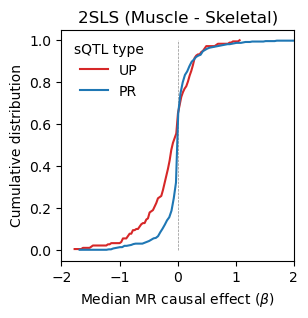

In [41]:
def get_cumulative(x, steps = 100):
    '''
    Function to get cumulative distribution.
    '''
    x = np.array(x)
    X = np.linspace(np.min(x), np.max(x), steps)
    y = [np.mean(x<=z) for z in X]
    return X, y

def prepare_qq(y_):

    min_non_zero = np.min([x for x in y_ if x > 0])

    y_ = np.maximum(np.array(y_), min_non_zero)
    y = sorted(-np.log10(np.array(y_)))
    x = sorted(-np.log10(np.linspace(1, len(y)+1, len(y))/len(y)))
    return x, y
    
mx_up, my_up = get_cumulative(aver_UP.loc[aver_UP.F >= 10].groupby('gene').intron_gene_beta.median())
mx_pr, my_pr = get_cumulative(aver_PR.loc[aver_PR.F >= 10].groupby('gene').intron_gene_beta.median())


fig, ax = plt.subplots(figsize=(3,3))
ax.plot([0, 0], [0, 1], c='grey', linestyle='--', linewidth=0.5, alpha = 0.9)
# ax.plot(x_up, y_up, c='tab:red', label='UP', linestyle='--')
# ax.plot(x_pr, y_pr, c='tab:blue', label='PR', linestyle='--')

ax.plot(mx_up, my_up, c='tab:red', label='UP')
ax.plot(mx_pr, my_pr, c='tab:blue', label='PR')
# plt.plot(sx_up, sy_up, c='tab:red')
# plt.plot(sx_pr, sy_pr, c='tab:blue')
ax.set_xlim([-2, 2])
ax.legend(frameon=False, title='sQTL type')
ax.set_xlabel(r'Median MR causal effect $(\beta)$')
ax.set_ylabel('Cumulative distribution')
ax.set_title('2SLS (Muscle - Skeletal)')


In [16]:
len(tissues)

# import warnings
# warnings.filterwarnings("ignore")
from tqdm import tqdm

In [ ]:
# mediation_stats_dict = {}
for tissue in tissues:
    aver = get_tissue_mediation_stats(tissue, vcf_in)
    aver['UP'].to_csv(f'MR_2SLS.{tissue}_UP.tab.gz', sep='\t', header=True, index = False)
    aver['PR'].to_csv(f'MR_2SLS.{tissue}_PR.tab.gz', sep='\t', header=True, index = False)

1750it [04:08,  7.04it/s]
5907it [13:22,  7.36it/s]
1363it [02:35,  8.79it/s]
4815it [09:08,  8.79it/s]
665it [00:56, 12.11it/s][W::hts_idx_load3] The index file is older than the data file: /project/yangili1/cfbuenabadn/SpliFi/code/results/eqtl/GTEx/AdrenalGland/qqnorm.sorted.chr20.bed.gz.tbi
[W::hts_idx_load3] The index file is older than the data file: /project/yangili1/cfbuenabadn/SpliFi/code/results/eqtl/GTEx/AdrenalGland/qqnorm.sorted.chr20.bed.gz.tbi
[W::hts_idx_load3] The index file is older than the data file: /project/yangili1/cfbuenabadn/SpliFi/code/results/eqtl/GTEx/AdrenalGland/qqnorm.sorted.chr20.bed.gz.tbi
667it [00:56,  9.48it/s][W::hts_idx_load3] The index file is older than the data file: /project/yangili1/cfbuenabadn/SpliFi/code/results/eqtl/GTEx/AdrenalGland/qqnorm.sorted.chr20.bed.gz.tbi
[W::hts_idx_load3] The index file is older than the data file: /project/yangili1/cfbuenabadn/SpliFi/code/results/eqtl/GTEx/AdrenalGland/qqnorm.sorted.chr20.bed.gz.tbi
[W::hts_idx_l

In [51]:
def get_cumulative(x, steps = 100):
    '''
    Function to get cumulative distribution.
    '''
    x = np.array(x)
    X = np.linspace(np.min(x), np.max(x), steps)
    y = [np.mean(x<=z) for z in X]
    return X, y

def prepare_qq(y_):

    min_non_zero = np.min([x for x in y_ if x > 0])

    y_ = np.maximum(np.array(y_), min_non_zero)
    y = sorted(-np.log10(np.array(y_)))
    x = sorted(-np.log10(np.linspace(1, len(y)+1, len(y))/len(y)))
    return x, y
    
mx_up, my_up = get_cumulative(aver['UP'].loc[(aver['UP'].F >= 10) & (aver['UP'].pval1 <= 1e-10)].groupby('gene').intron_gene_beta.median())
mx_pr, my_pr = get_cumulative(aver['PR'].loc[(aver['PR'].F >= 10) & (aver['PR'].pval1 <= 1e-10)].groupby('gene').intron_gene_beta.median())

x_up, y_up = get_cumulative(aver['UP'].loc[aver['UP'].F >= 10].intron_gene_beta)
x_pr, y_pr = get_cumulative(aver['PR'].loc[aver['PR'].F >= 10].intron_gene_beta)



NameError: name 'pd' is not defined

Text(0.5, 1.0, '2SLS (Muscle - Skeletal), eQTL pval <= 1e-10')

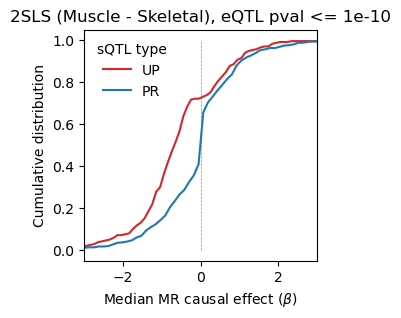

In [52]:
fig, ax = plt.subplots(figsize=(3,3))
ax.plot([0, 0], [0, 1], c='grey', linestyle='--', linewidth=0.5, alpha = 0.9)
# ax.plot(x_up, y_up, c='tab:red', label='UP', linestyle='--')
# ax.plot(x_pr, y_pr, c='tab:blue', label='PR', linestyle='--')

ax.plot(mx_up, my_up, c='tab:red', label='UP')
ax.plot(mx_pr, my_pr, c='tab:blue', label='PR')
# plt.plot(sx_up, sy_up, c='tab:red')
# plt.plot(sx_pr, sy_pr, c='tab:blue')
ax.set_xlim([-3, 3])
ax.legend(frameon=False, title='sQTL type')
ax.set_xlabel(r'Median MR causal effect $(\beta)$')
ax.set_ylabel('Cumulative distribution')
ax.set_title('2SLS (Muscle - Skeletal), eQTL pval <= 1e-10')

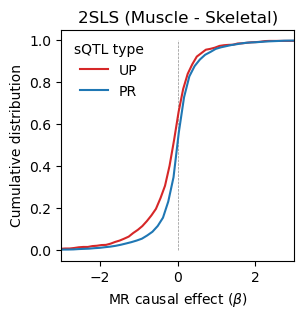

In [444]:
fig, ax = plt.subplots(figsize=(3,3))
ax.plot([0, 0], [0, 1], c='grey', linestyle='--', linewidth=0.5, alpha = 0.9)
# ax.plot(x_up, y_up, c='tab:red', label='UP', linestyle='--')
# ax.plot(x_pr, y_pr, c='tab:blue', label='PR', linestyle='--')

ax.plot(x_up, y_up, c='tab:red', label='UP')
ax.plot(x_pr, y_pr, c='tab:blue', label='PR')
# plt.plot(sx_up, sy_up, c='tab:red')
# plt.plot(sx_pr, sy_pr, c='tab:blue')
ax.set_xlim([-3, 3])
ax.legend(frameon=False, title='sQTL type')
ax.set_xlabel(r'MR causal effect $(\beta)$')
ax.set_ylabel('Cumulative distribution')
ax.set_title('2SLS (Muscle - Skeletal)')

plt.savefig('../code/revision_plots/2SLS_muscle.png', dpi=300, bbox_inches='tight')
plt.savefig('../code/revision_plots/2SLS_muscle.pdf', dpi=300, bbox_inches='tight')
plt.savefig('../code/revision_plots/2SLS_muscle.svg', dpi=300, bbox_inches='tight')   

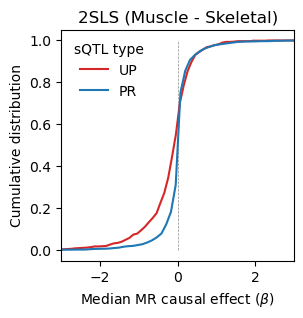

In [445]:
fig, ax = plt.subplots(figsize=(3,3))
ax.plot([0, 0], [0, 1], c='grey', linestyle='--', linewidth=0.5, alpha = 0.9)
# ax.plot(x_up, y_up, c='tab:red', label='UP', linestyle='--')
# ax.plot(x_pr, y_pr, c='tab:blue', label='PR', linestyle='--')

ax.plot(mx_up, my_up, c='tab:red', label='UP')
ax.plot(mx_pr, my_pr, c='tab:blue', label='PR')
# plt.plot(sx_up, sy_up, c='tab:red')
# plt.plot(sx_pr, sy_pr, c='tab:blue')
ax.set_xlim([-3, 3])
ax.legend(frameon=False, title='sQTL type')
ax.set_xlabel(r'Median MR causal effect $(\beta)$')
ax.set_ylabel('Cumulative distribution')
ax.set_title('2SLS (Muscle - Skeletal)')

plt.savefig('../code/revision_plots/2SLS_muscle_median.png', dpi=300, bbox_inches='tight')
plt.savefig('../code/revision_plots/2SLS_muscle_median.pdf', dpi=300, bbox_inches='tight')
plt.savefig('../code/revision_plots/2SLS_muscle_median.svg', dpi=300, bbox_inches='tight')   

In [447]:
qqx_up, qqy_up = prepare_qq(aver['UP'].itron_gene_pval)
qqx_pr, qqy_pr = prepare_qq(aver['PR'].itron_gene_pval)

mqqx_up, mqqy_up = prepare_qq(aver['UP'].groupby('gene').itron_gene_pval.median())
mqqx_pr, mqqy_pr = prepare_qq(aver['PR'].groupby('gene').itron_gene_pval.median())

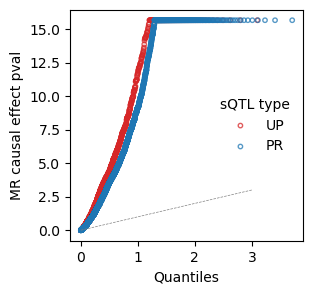

In [450]:
fig, ax = plt.subplots(figsize=(3,3))
# ax.plot([0, 0], [0, 1], c='grey', linestyle='--', linewidth=0.5, alpha = 0.9)
ax.scatter(qqx_up, qqy_up, label='UP', facecolor='none', edgecolor = 'tab:red', s=10, alpha=0.75, rasterized=True)
ax.scatter(qqx_pr, qqy_pr, label='PR', facecolor='none', edgecolor = 'tab:blue', s=10, alpha=0.75, rasterized=True)
ax.plot([0, 3], [0, 3], linestyle = '--', linewidth=0.5, c='grey')
# plt.plot(sx_up, sy_up, c='tab:red')
# plt.plot(sx_pr, sy_pr, c='tab:blue')
# ax.set_xlim([-3, 3])
ax.legend(frameon=False, title='sQTL type')
ax.set_ylabel(r'MR causal effect pval')
ax.set_xlabel('Quantiles')

plt.savefig('../code/revision_plots/2SLS_muscle_pvals.png', dpi=300, bbox_inches='tight')
plt.savefig('../code/revision_plots/2SLS_muscle_pvals.pdf', dpi=300, bbox_inches='tight')
plt.savefig('../code/revision_plots/2SLS_muscle_pvals.svg', dpi=300, bbox_inches='tight')   

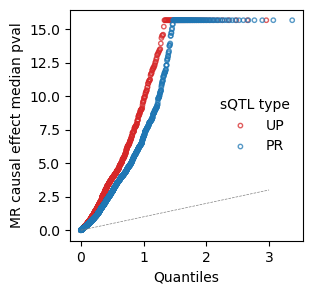

In [451]:
fig, ax = plt.subplots(figsize=(3,3))
# ax.plot([0, 0], [0, 1], c='grey', linestyle='--', linewidth=0.5, alpha = 0.9)
ax.scatter(mqqx_up, mqqy_up, label='UP', facecolor='none', edgecolor = 'tab:red', s=10, alpha=0.75, rasterized=True)
ax.scatter(mqqx_pr, mqqy_pr, label='PR', facecolor='none', edgecolor = 'tab:blue', s=10, alpha=0.75, rasterized=True)
ax.plot([0, 3], [0, 3], linestyle = '--', linewidth=0.5, c='grey')
# plt.plot(sx_up, sy_up, c='tab:red')
# plt.plot(sx_pr, sy_pr, c='tab:blue')
# ax.set_xlim([-3, 3])
ax.legend(frameon=False, title='sQTL type')
ax.set_ylabel(r'MR causal effect median pval')
ax.set_xlabel('Quantiles')

plt.savefig('../code/revision_plots/2SLS_muscle_pvals_median.png', dpi=300, bbox_inches='tight')
plt.savefig('../code/revision_plots/2SLS_muscle_pvals_median.pdf', dpi=300, bbox_inches='tight')
plt.savefig('../code/revision_plots/2SLS_muscle_pvals_median.svg', dpi=300, bbox_inches='tight')   

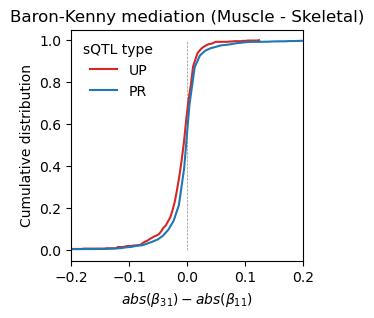

In [454]:
x_up, y_up = get_cumulative(aver['UP'].loc[aver['UP'][['pval1', 'pval2', 'pval3']].max(axis=1) < 0.01].abs_beta_diff)
x_pr, y_pr = get_cumulative(aver['PR'].loc[aver['PR'][['pval1', 'pval2', 'pval3']].max(axis=1) < 0.01].abs_beta_diff)

fig, ax = plt.subplots(figsize=(3,3))
ax.plot([0, 0], [0, 1], c='grey', linestyle='--', linewidth=0.5, alpha = 0.9)
ax.plot(x_up, y_up, c='tab:red', label='UP')
ax.plot(x_pr, y_pr, c='tab:blue', label='PR')
# plt.plot(sx_up, sy_up, c='tab:red')
# plt.plot(sx_pr, sy_pr, c='tab:blue')
ax.set_xlim([-0.2, 0.2])
ax.legend(frameon=False, title='sQTL type')
ax.set_xlabel(r'$abs(\beta_{31}) - abs(\beta_{11})$')
ax.set_ylabel('Cumulative distribution')
ax.set_title('Baron-Kenny mediation (Muscle - Skeletal)')

plt.savefig('../code/revision_plots/BaronKenny_muscle.png', dpi=300, bbox_inches='tight')
plt.savefig('../code/revision_plots/BaronKenny_muscle.pdf', dpi=300, bbox_inches='tight')
plt.savefig('../code/revision_plots/BaronKenny_muscle.svg', dpi=300, bbox_inches='tight')   

In [455]:
aver['UP']['beta_diff'] = aver['UP'].beta_3 - aver['UP'].beta_1
aver['UP']['abs_beta_diff'] = aver['UP'].beta_3.abs() - aver['UP'].beta_1.abs()

aver['PR']['beta_diff'] = aver['PR'].beta_3 - aver['PR'].beta_1
aver['PR']['abs_beta_diff'] = aver['PR'].beta_3.abs() - aver['PR'].beta_1.abs()

x_up, y_up = get_cumulative(aver['UP'].loc[aver['UP'][['pval1', 'pval2', 'pval3']].max(axis=1) < 0.01].groupby('gene').abs_beta_diff.median())
x_pr, y_pr = get_cumulative(aver['PR'].loc[aver['PR'][['pval1', 'pval2', 'pval3']].max(axis=1) < 0.01].groupby('gene').abs_beta_diff.median())

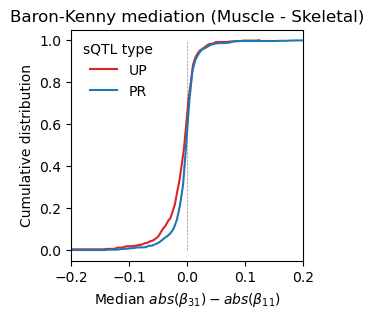

In [456]:
fig, ax = plt.subplots(figsize=(3,3))
ax.plot([0, 0], [0, 1], c='grey', linestyle='--', linewidth=0.5, alpha = 0.9)
ax.plot(x_up, y_up, c='tab:red', label='UP')
ax.plot(x_pr, y_pr, c='tab:blue', label='PR')
# plt.plot(sx_up, sy_up, c='tab:red')
# plt.plot(sx_pr, sy_pr, c='tab:blue')
ax.set_xlim([-0.2, 0.2])
ax.legend(frameon=False, title='sQTL type')
ax.set_xlabel(r'Median $abs(\beta_{31}) - abs(\beta_{11})$')
ax.set_ylabel('Cumulative distribution')
ax.set_title('Baron-Kenny mediation (Muscle - Skeletal)')


plt.savefig('../code/revision_plots/BaronKenny_muscle_median.png', dpi=300, bbox_inches='tight')
plt.savefig('../code/revision_plots/BaronKenny_muscle_median.pdf', dpi=300, bbox_inches='tight')
plt.savefig('../code/revision_plots/BaronKenny_muscle_median.svg', dpi=300, bbox_inches='tight')  

In [332]:
aver['UP'].loc[aver['UP'].F >= 50].intron_gene_beta.median()

np.float64(-0.1067309045473313)

In [ ]:
mediation_stats.loc[mediation_stats.F >= 10].groupby('gene').intron_gene_beta.median().median()

In [314]:
(aver['PR'].loc[aver['PR'][['pval1', 'pval2', 'pval3']].max(axis=1) < 0.0001].beta_3.abs() - aver['PR'].loc[aver['PR'][['pval1', 'pval2', 'pval3']].max(axis=1) < 0.0001].beta_1.abs()).median()

np.float64(-0.002975570362765398)

In [303]:
(aver['PR'].beta_3.abs() - aver['PR'].beta_1.abs()).median()

np.float64(-0.0009371020567099046)

In [262]:
from tqdm import tqdm 
mediation_stats = []
i = 0
for idx, row in tqdm(perm_select.iterrows()):
    try:
        row_stats = process_perm_row(row, 'Muscle-Skeletal', vcf_in)
        mediation_stats.append(row_stats)
    except:
        continue
    # i += 1

    # if i >= 10:
    #     break

mediation_stats = pd.DataFrame(mediation_stats, 
             columns = ['intron', 'gene', 'var', 'F', 'intron_gene_beta', 'itron_gene_pval', 'pval1', 'pval2', 'pval3', 'beta_1', 'beta_3'])

492it [01:21,  5.81it/s][W::hts_idx_load3] The index file is older than the data file: /project/yangili1/cfbuenabadn/SpliFi/code/results/pheno/noisy/GTEx/Muscle-Skeletal/separateNoise/leafcutter.qqnorm_chr7.gz.tbi
[W::hts_idx_load3] The index file is older than the data file: /project/yangili1/cfbuenabadn/SpliFi/code/results/pheno/noisy/GTEx/Muscle-Skeletal/separateNoise/leafcutter.qqnorm_chr7.gz.tbi
493it [01:22,  5.82it/s][W::hts_idx_load3] The index file is older than the data file: /project/yangili1/cfbuenabadn/SpliFi/code/results/pheno/noisy/GTEx/Muscle-Skeletal/separateNoise/leafcutter.qqnorm_chr7.gz.tbi
[W::hts_idx_load3] The index file is older than the data file: /project/yangili1/cfbuenabadn/SpliFi/code/results/pheno/noisy/GTEx/Muscle-Skeletal/separateNoise/leafcutter.qqnorm_chr7.gz.tbi
494it [01:22,  5.80it/s][W::hts_idx_load3] The index file is older than the data file: /project/yangili1/cfbuenabadn/SpliFi/code/results/pheno/noisy/GTEx/Muscle-Skeletal/separateNoise/leafcutt

In [311]:
np.median(mediation_stats.loc[mediation_stats[['pval1', 'pval2', 'pval3']].max(axis=1) <= 0.01].beta_3.abs() - mediation_stats.loc[mediation_stats[['pval1', 'pval2', 'pval3']].max(axis=1) <= 0.01].beta_1.abs())

np.float64(-0.005980516796462068)

In [292]:
mediation_stats.loc[mediation_stats.F >= 10].groupby('gene').intron_gene_beta.median().median()

np.float64(-0.09347670064247329)

In [307]:
np.median(mediation_stats.beta_1.abs() - mediation_stats.beta_3.abs())

np.float64(0.003346518456521924)

In [221]:
mediation_stats.loc[mediation_stats[['pval1', 'pval2', 'pval3']].max(axis=1) < 0.05]

,intron,gene,var,F,intron_gene_beta,itron_gene_pval,pval1,pval2,pval3,beta_1,beta_3
0,chr1:954523:955922:clu_1985_-:UP,ENSG00000188976,chr1_954333_C_A_b38,48.124664,0.260248,0.001050,0.000182,1.348134e-12,0.000009,-0.121245,-0.149023
18,chr1:19374455:19378539:clu_2227_-:UP,ENSG00000077549,chr1_19443667_C_G_b38,48.124664,0.589595,0.151411,0.036865,3.284270e-02,0.023782,0.111989,0.121436


In [223]:
def get_sqtl_expression_effects(perm_counts, tissue, ctype='PR,UP', itype='UP', qmax = 1e-2, clu_psi_min=0.1):
    sqtl_slopes = []
    eqtl_slopes = []
    eqtl_pvals = []

    perm_select = perm_counts.loc[(perm_counts.ctype == ctype) & (perm_counts.itype == itype) & (perm_counts.q <= qmax) & (perm_counts.cluster_psi >= clu_psi_min)]
    # idx = perm_counts.loc[(perm_counts.ctype == 'PR,UP') & (perm_counts.itype == 'UP') & (perm_counts.q <= 1e-2)].groupby('gene_id').median_counts.idxmax()
    # perm_select = perm_counts.loc[idx]

#     print(perm_select.columns)
    for idx, row in perm_select.iterrows():
        try:
            eqtl_df = get_expression_effect(tissue, row)
            if eqtl_df.shape[0] > 0:
                eqtl_effect = float(eqtl_df.iloc[0].slope)#/float(eqtl_df.iloc[0].slope_se)
                sqtl_slopes.append(float(row.slope))#/float(row.slope_se))
                eqtl_slopes.append(float(eqtl_effect))
                eqtl_pvals.append(float(eqtl_df.iloc[0].nom_pval))
        except:
            continue
        
    return sqtl_slopes, eqtl_slopes, eqtl_pvals

In [224]:
# perm_counts = get_perm_counts(tissue)
u_sqtl_effects = get_sqtl_expression_effects(perm_select, 'Muscle-Skeletal', ctype='PR,UP', itype='UP', qmax = 1e-1, clu_psi_min=0.1)
# p_sqtl_effects = get_sqtl_expression_effects(perm_select, tissue, ctype='PR,UP', itype='PR', qmax = 1e-1, clu_psi_min=0.1)
# pp_sqtl_effects = get_sqtl_expression_effects(perm_select, tissue, ctype='PR', itype='PR', qmax = 1e-1, clu_psi_min=0.1)

In [245]:
perm_select.iloc[4]

intron               chr1:1915735:1916751:clu_46_+
cluster                              chr1:clu_46_+
itype                                           UP
ctype                                        PR,UP
gene_name                                   CALML6
gene_id                          ENSG00000169885.9
phe_id            chr1:1915735:1916751:clu_46_+:UP
phe_chr                                       chr1
phe_from                                   1915736
phe_to                                     1916751
phe_strd                                         +
n_var_in_cis                                   532
dist_phe_var                                 10119
var_id                        chr1_1926870_T_C_b38
var_chr                                       chr1
var_from                                   1926870
var_to                                     1926870
dof1                                           704
dof2                                       624.267
bml1                           

In [244]:
u_sqtl_effects[2][4]

4.6566e-18

In [246]:
mediation_stats.iloc[4]

intron              chr1:1915735:1916751:clu_46_+:UP
gene                                 ENSG00000169885
var                             chr1_1926870_T_C_b38
F                                          48.124664
intron_gene_beta                           -0.241114
itron_gene_pval                             0.489918
pval1                                       0.541864
pval2                                       0.091781
pval3                                       0.941068
beta_1                                      0.038328
beta_3                                      0.004414
Name: 4, dtype: object

In [240]:
mediation_stats#.intron_gene_beta.median()

,intron,gene,var,F,intron_gene_beta,itron_gene_pval,pval1,pval2,pval3,beta_1,beta_3
0,chr1:954523:955922:clu_1985_-:UP,ENSG00000188976,chr1_954333_C_A_b38,48.124664,0.260248,0.001050,0.000182,1.348134e-12,0.000009,-0.121245,-0.149023
1,chr1:1374590:1374704:clu_2012_-:UP,ENSG00000175756,chr1_1374505_A_G_b38,48.124664,-0.467213,0.465971,0.421221,5.307027e-01,0.488441,-0.026667,-0.022534
2,chr1:1642508:1649498:clu_2023_-:UP,ENSG00000248333,chr1_1627156_G_A_b38,48.124664,1.190942,0.711509,0.259348,7.128102e-01,0.249543,-0.043306,-0.044167
3,chr1:1703995:1704222:clu_2028_-:UP,ENSG00000008128,chr1_1696758_A_G_b38,48.124664,0.433764,0.587255,0.566334,2.417191e-01,0.521149,0.038139,0.042677
4,chr1:1915735:1916751:clu_46_+:UP,ENSG00000169885,chr1_1926870_T_C_b38,48.124664,-0.241114,0.489918,0.541864,9.178084e-02,0.941068,0.038328,0.004414
...,...,...,...,...,...,...,...,...,...,...,...
1300,chr22:46735508:46738006:clu_38294_-:UP,ENSG00000100422,chr22_46738358_A_G_b38,48.124664,0.034901,0.893166,0.893969,4.599635e-02,0.720239,0.007024,0.018828
1301,chr22:49921761:49921870:clu_37868_+:UP,ENSG00000184164,chr22_49921859_C_CT_b38,48.124664,-0.568276,0.198909,0.073383,1.212329e-01,0.079736,-0.078626,-0.077128
1302,chr22:50206520:50208487:clu_37875_+:UP,ENSG00000073169,chr22_50208507_G_C_b38,48.124664,2.551693,0.802964,0.212858,8.062673e-01,0.219398,0.064312,0.063215
1303,chr22:50258301:50260828:clu_38317_-:UP,ENSG00000188130,chr22_50260902_C_G_b38,48.124664,-1.699400,0.628247,0.135416,6.401031e-01,0.128848,-0.081907,-0.083273


In [225]:
u_sqtl_effects[0]

[-0.451874,
 -0.458747,
 -0.35119,
 0.22711,
 -0.573816,
 0.463829,
 0.304047,
 0.278537,
 -0.227409,
 0.338398,
 -0.19551,
 0.21439,
 0.176009,
 -0.266917,
 -0.187157,
 -0.315909,
 -0.298338,
 -0.332279,
 0.312486,
 -0.386407,
 -0.294541,
 -0.3547,
 0.498606,
 0.62321,
 0.162961,
 1.03412,
 0.473731,
 -0.409971,
 -0.266546,
 -0.203583,
 -0.262244,
 -0.211235,
 -0.357005,
 -0.561562,
 0.235719,
 0.584989,
 -0.410625,
 1.13574,
 0.79802,
 0.263132,
 -0.379231,
 -0.236687,
 -0.218531,
 0.223143,
 -1.15341,
 -0.3288,
 -0.41389,
 -0.376605,
 -0.271495,
 0.315243,
 0.325744,
 0.927495,
 -1.84693,
 -0.684114,
 -0.360705,
 -0.531813,
 1.76961,
 -0.59965,
 -0.448604,
 1.54602,
 0.424395,
 0.224279,
 0.623091,
 -0.366438,
 -0.419776,
 -0.255841,
 -0.450454,
 0.301465,
 -0.341411,
 -0.13985,
 -0.171186,
 0.143334,
 -0.62618,
 0.77186,
 -0.374315,
 -0.286634,
 0.805694,
 0.654388,
 1.28612,
 -0.382989,
 0.328022,
 0.175842,
 -0.386067,
 0.301039,
 0.201306,
 -0.196507,
 0.197587,
 -0.310066,
 -0.

In [257]:
iv_df = get_iv_input(stbx, etbx, 'chr1:1915735:1916751:clu_46_+:UP', 'ENSG00000169885', vcf_in, 'chr1_1926870_T_C_b38')

In [258]:
merged_iv = iv_df.merge(pca.T, left_index = True, right_index=True)

<Axes: xlabel='genotype', ylabel='pheno_intron'>

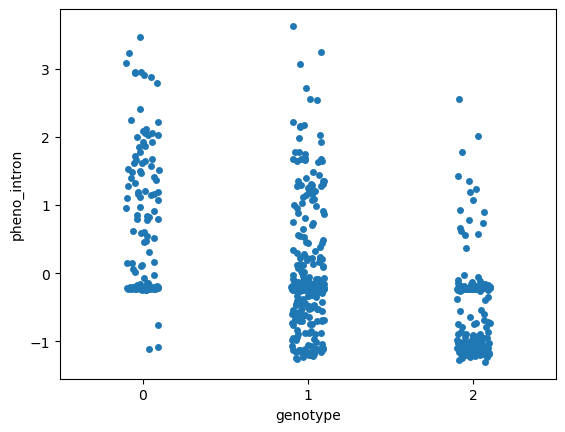

In [259]:
sns.stripplot(data = merged_iv, x = 'genotype', y = 'pheno_intron')

In [134]:
get_expression_effect('Muscle-Skeletal', perm_select.iloc[0])

In [10]:
import statsmodels.api as sm

def baron_kenny_mediation(merged_iv):
    covariates = merged_iv.columns[3:]

    XG_cov   = sm.add_constant(pd.concat([merged_iv['genotype'], merged_iv[covariates]], axis=1))
    XG_I_cov  = sm.add_constant(pd.concat([merged_iv[['genotype', 'pheno_intron']], merged_iv[covariates]], axis=1))

    # Step 1: total genetic effect on expression
    step1 = sm.OLS(merged_iv['pheno_gene'], XG_cov).fit()

    # Step 2: UP splicing path
    step2 = sm.OLS(merged_iv['pheno_intron'], XG_cov).fit()

    # Step 3: mediated analysis
    step3 = sm.OLS(merged_iv['pheno_gene'], XG_I_cov).fit()

    return step1, step2, step3
    
    # print(model_c.summary())
    # print(model_a.summary())
    # print(model_bc.summary())


from linearmodels.iv import IV2SLS

def MR2SLS(merged_iv):
    covariates = merged_iv.columns[3:]
    covs_formula = ' + '.join(covariates)
    formula = 'pheno_gene ~ 1 + ' + covs_formula +' + [pheno_intron ~ genotype]'


    # 2SLS with covariates
    model = IV2SLS.from_formula(
        formula,
        data=merged_iv
    )

    results = model.fit(cov_type='robust')
    return (results)


def get_2SLS_results(merged_iv):
    results = MR2SLS(merged_iv)
    first_stage_F = results.first_stage.diagnostics.loc['pheno_intron', 'f.stat']
    intron_gene_beta = results.params['pheno_intron']
    intron_gene_pval = results.pvalues['pheno_intron']

    return first_stage_F, intron_gene_beta, intron_gene_pval


def get_baron_kenny_results(merged_iv):
    step1, step2, step3 = baron_kenny_mediation(merged_iv)
    pval_1 = step1.pvalues.loc['genotype']
    pval_2 = step2.pvalues.loc['genotype']
    pval_3 = step3.pvalues.loc['genotype']

    beta_step1 = step1.params.loc['genotype']
    beta_step3 = step3.params.loc['genotype']

    return pval_1, pval_2, pval_3, beta_step1, beta_step3

In [187]:
model_c.params.loc['genotype']

np.float64(-0.12124483150919833)

In [190]:
model_bc.params.loc['genotype']

np.float64(-0.14902314324232208)

In [188]:
model_c.pvalues.loc['genotype']

np.float64(0.0001819931176455067)

In [189]:
model_a.pvalues.loc['genotype']

np.float64(1.3481336488222153e-12)

In [192]:
model_bc.pvalues.loc['pheno_intron']

np.float64(0.0023779080717041884)

In [144]:
aver = MR2SLS(merged_iv)

     First Stage Estimation Results    
                           pheno_intron
---------------------------------------
R-squared                        0.5891
Partial R-squared                0.0749
Shea's R-squared                 0.0749
Partial F-statistic              48.125
P-value (Partial F-stat)          4e-12
Partial F-stat Distn            chi2(1)
==========================  ===========
Intercept                        0.8217
                               (6.3458)
PC1                              0.0032
                               (6.9961)
PC2                              0.0120
                               (17.918)
PC3                             -0.0007
                              (-0.8948)
PC4                              0.0086
                               (9.0949)
PC5                             -0.0005
                              (-0.5945)
PC6                             -0.0075
                              (-6.7464)
PC7                             -0.0126


In [176]:
aver.params['pheno_intron']

np.float64(0.26024838010645945)

In [156]:
aver.pvalues['pheno_intron']

np.float64(0.0010496967732243068)

In [175]:
aver.first_stage.diagnostics.loc['pheno_intron', 'f.stat']

np.float64(48.124663764900035)

In [174]:
aver.first_stage.summary

,pheno_intron
R-squared,0.5891
Partial R-squared,0.0749
Shea's R-squared,0.0749
Partial F-statistic,48.125
P-value (Partial F-stat),4e-12
Partial F-stat Distn,chi2(1)
==========================,===========
Intercept,0.8217
,(6.3458)
PC1,0.0032


In [ ]:
genotype      -0.1212      0.032     -3.765      0.000      -0.184      -0.058
genotype      -0.4659      0.064     -7.232      0.000      -0.592      -0.339


genotype        -0.1490      0.033     -4.479      0.000      -0.214      -0.084
pheno_intron    -0.0596      0.020     -3.051      0.002      -0.098      -0.021

In [59]:
pca = pd.read_csv('/project/yangili1/cfbuenabadn/SpliFi/code/results/eqtl/GTEx/Muscle-Skeletal/qqnorm.sorted.bed.pca', sep=' ', index_col = 0)

In [60]:
pca

,GTEX-1117F,GTEX-111CU,GTEX-111FC,GTEX-111VG,GTEX-111YS,GTEX-1122O,GTEX-1128S,GTEX-113JC,GTEX-117XS,GTEX-117YW,...,GTEX-ZY6K,GTEX-ZYFC,GTEX-ZYFD,GTEX-ZYFG,GTEX-ZYT6,GTEX-ZYW4,GTEX-ZYY3,GTEX-ZZ64,GTEX-ZZPT,GTEX-ZZPU
SampleID,,,,,,,,,,,,,,,,,,,,,
PC1,-22.83615,-64.53026,79.56676,76.97281,-44.37724,-71.51562,-17.96726,78.09928,78.31423,69.09543,...,-13.40278,79.60918,38.15923,-58.36040,67.90022,7.50747,-38.65083,-28.47555,-35.11354,-56.46053
PC2,54.16771,-26.14475,-12.29531,-24.75547,-14.63237,5.37714,2.00023,-6.37030,-24.12554,-32.98873,...,18.33205,-12.26715,-2.08547,-19.53324,-48.51767,62.81735,38.73036,-0.40835,70.37971,-25.51764
PC3,-12.39387,10.25493,-29.69672,-12.28527,55.03529,21.90583,-47.34034,-2.44376,-2.39195,6.26282,...,-41.04699,-13.42158,-3.05255,-20.74041,-1.68613,17.28842,-26.79697,62.78680,-28.96254,16.54429
PC4,26.63597,-9.26724,-8.14494,-5.59523,4.88301,13.71708,16.15710,4.44651,-5.68346,21.48935,...,-13.22990,18.28517,39.22096,21.36618,-5.07904,38.00576,35.00921,-22.00096,-26.42520,-3.06396
PC5,-19.16110,12.03495,-25.16981,-10.24336,-15.04264,6.53260,-36.24590,-21.10559,-19.95796,1.79707,...,1.32388,7.88403,-61.57963,24.85073,-9.21701,-22.18404,2.31513,-19.69359,3.31800,21.17591
PC6,34.04375,-18.12500,-22.62070,2.66517,-24.27126,-8.55397,21.44196,-9.21158,8.92872,19.07382,...,-20.73907,-7.04066,-2.90865,-14.11129,10.90738,21.05939,6.08737,-10.61750,-13.16015,-29.35477
PC7,-38.57599,11.01565,10.66934,-15.89830,21.34370,16.05352,15.82890,4.09505,6.59505,6.19411,...,11.46157,5.44666,9.73620,10.00577,-14.26398,-22.96636,-30.19790,-21.81755,17.70456,-17.75542
PC8,18.50823,-7.23372,12.61006,-7.19743,14.50389,26.67806,22.85188,0.64123,3.48400,-16.75113,...,-16.33014,-2.11613,-24.49481,15.31210,-0.69424,24.63744,-24.47072,24.80465,11.15613,2.38068
PC9,-24.19083,3.48803,-11.41342,13.69234,28.74191,35.74048,-13.62735,-11.94690,12.59689,2.15290,...,41.79275,-5.62258,-7.56011,17.32092,-6.46521,-15.35978,5.29917,-16.56693,-18.33289,8.37412


In [35]:
record_var = fetch_variant(vcf_in, 'chr1_954333_C_A_b38')

In [45]:
np.sum(dict(record_var.samples.items())['GTEX-1117F']['GT'])

np.int64(2)

In [51]:
etbx.header[0] == stbx.header[0]

True

In [49]:
fetch_genotypes(vcf_in, 'chr1_954333_C_A_b38', etbx.header[0].rstrip().split('\t')[6:])

[np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(1),
 np.int64(1),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(1),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(0),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(1),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(1),
 np.int64(2),
 np.int64(1),
 np.int64(2),
 np.int64(2),
 np.int64(1),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(1),
 np.int64(2),
 np.int64(2),
 np.int64(1),
 np.in